importing libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

In [3]:
df = pd.read_csv("stress_level.csv")

print(df.head())

    Age  Gender  Sleep_Hours  Work_Hours  Screen_Time  Physical_Activity  \
0  56.0  Female          8.0         5.3          5.2                3.1   
1  46.0  Female          5.4         2.2          8.3                3.9   
2  32.0    Male          6.0         9.5          9.0                2.2   
3  25.0  Female          3.9         9.9          5.2                2.2   
4  38.0    Male          5.4         3.1          NaN                1.8   

   Heart_Rate  Blood_Pressure  Anxiety_Score  Depression_Score  \
0        91.0            90.0            8.0               1.0   
1       111.0            95.0            5.0               4.0   
2        94.0           118.0            7.0               4.0   
3        57.0           120.0            5.0               5.0   
4       110.0            99.0            NaN               4.0   

   Social_Interaction  Financial_Stress  Academic_Pressure  Family_Pressure  \
0                 3.0              10.0                8.0         

In [4]:
print(df.shape)

print(df.info())

print(df.describe())

(100000, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  95000 non-null  float64
 1   Gender               95000 non-null  object 
 2   Sleep_Hours          95000 non-null  float64
 3   Work_Hours           95000 non-null  float64
 4   Screen_Time          95000 non-null  float64
 5   Physical_Activity    95000 non-null  float64
 6   Heart_Rate           95000 non-null  float64
 7   Blood_Pressure       95000 non-null  float64
 8   Anxiety_Score        95000 non-null  float64
 9   Depression_Score     95000 non-null  float64
 10  Social_Interaction   95000 non-null  float64
 11  Financial_Stress     95000 non-null  float64
 12  Academic_Pressure    95000 non-null  float64
 13  Family_Pressure      95000 non-null  float64
 14  Caffeine_Intake      95000 non-null  float64
 15  Smoking              9

checking missing values

In [5]:
print(df.isnull().sum())

Age                    5000
Gender                 5000
Sleep_Hours            5000
Work_Hours             5000
Screen_Time            5000
Physical_Activity      5000
Heart_Rate             5000
Blood_Pressure         5000
Anxiety_Score          5000
Depression_Score       5000
Social_Interaction     5000
Financial_Stress       5000
Academic_Pressure      5000
Family_Pressure        5000
Caffeine_Intake        5000
Smoking                5000
Alcohol_Consumption    5000
Meditation_Hours       5000
BMI                    5000
Stress_Level            593
dtype: int64


checking duplicate records

In [7]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 314


removing duplicate records

In [8]:
df = df.drop_duplicates()

print(df.shape)

(99686, 20)


Handling missing values (numerical columns)

In [9]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\ins1q\AppData\Local\Temp\ipykernel_27232\3551297251.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\ins1q\AppData\Local\Temp\ipykernel_27232\3551297251.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

for categorical columns

In [11]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\ins1q\AppData\Local\Temp\ipykernel_27232\2422164989.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [12]:
print(df.isnull().sum())

Age                    0
Gender                 0
Sleep_Hours            0
Work_Hours             0
Screen_Time            0
Physical_Activity      0
Heart_Rate             0
Blood_Pressure         0
Anxiety_Score          0
Depression_Score       0
Social_Interaction     0
Financial_Stress       0
Academic_Pressure      0
Family_Pressure        0
Caffeine_Intake        0
Smoking                0
Alcohol_Consumption    0
Meditation_Hours       0
BMI                    0
Stress_Level           0
dtype: int64


encoding categorical variables

In [13]:
le = LabelEncoder()

In [14]:
df['Gender'] = le.fit_transform(df['Gender'])

In [15]:
df['Smoking'] = le.fit_transform(df['Smoking'])

In [16]:
df['Alcohol_Consumption'] = le.fit_transform(df['Alcohol_Consumption'])

In [17]:
df['Stress_Level'] = le.fit_transform(df['Stress_Level'])

In [18]:
print(df.head())

    Age  Gender  Sleep_Hours  Work_Hours  Screen_Time  Physical_Activity  \
0  56.0       0          8.0         5.3          5.2                3.1   
1  46.0       0          5.4         2.2          8.3                3.9   
2  32.0       1          6.0         9.5          9.0                2.2   
3  25.0       0          3.9         9.9          5.2                2.2   
4  38.0       1          5.4         3.1          6.5                1.8   

   Heart_Rate  Blood_Pressure  Anxiety_Score  Depression_Score  \
0        91.0            90.0            8.0               1.0   
1       111.0            95.0            5.0               4.0   
2        94.0           118.0            7.0               4.0   
3        57.0           120.0            5.0               5.0   
4       110.0            99.0            5.0               4.0   

   Social_Interaction  Financial_Stress  Academic_Pressure  Family_Pressure  \
0                 3.0              10.0                8.0         

correlation heatmap

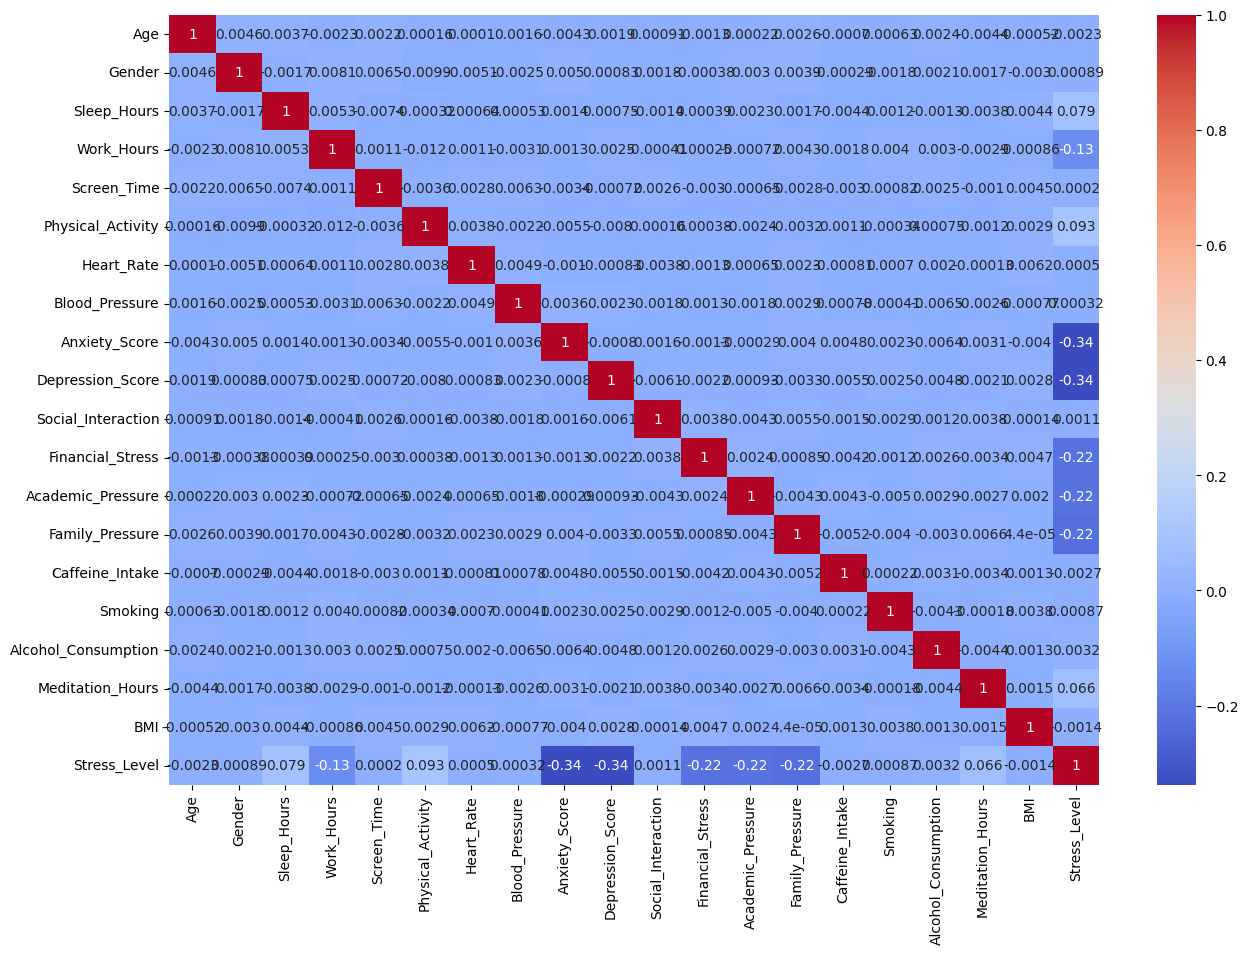

In [19]:
plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

splitting features and target

In [20]:
X = df.drop('Stress_Level', axis=1)

y = df['Stress_Level']

train test split

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

feature scaling

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

logistic regression

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create Model
lr = LogisticRegression(max_iter=1000)

# Train Model
lr.fit(X_train, y_train)

# Prediction
y_pred = lr.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9639382084461832

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     16320
           1       0.91      0.75      0.82       318
           2       0.90      0.88      0.89      3300

    accuracy                           0.96     19938
   macro avg       0.93      0.87      0.90     19938
weighted avg       0.96      0.96      0.96     19938


Confusion Matrix:
[[16081     0   239]
 [    0   238    80]
 [  376    24  2900]]


confusion matrix

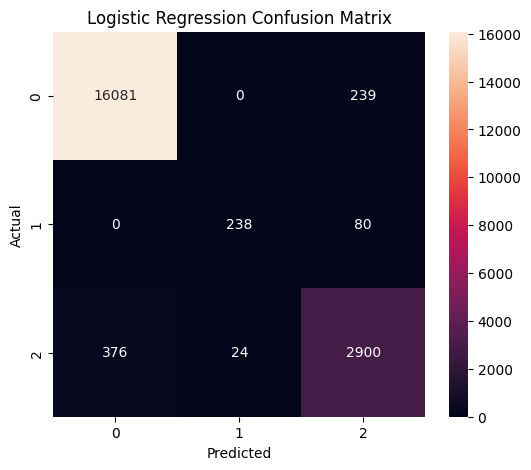

In [24]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

decision tree algorithm

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create Model
dt = DecisionTreeClassifier(random_state=42)

# Train Model
dt.fit(X_train, y_train)

# Prediction
y_pred_dt = dt.predict(X_test)

# Accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print(f"Accuracy: {accuracy_dt*100:.2f}%")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Accuracy: 88.05%

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94     16320
           1       0.50      0.49      0.50       318
           2       0.64      0.64      0.64      3300

    accuracy                           0.88     19938
   macro avg       0.69      0.69      0.69     19938
weighted avg       0.88      0.88      0.88     19938


Confusion Matrix:
[[15274    13  1033]
 [   12   157   149]
 [ 1034   141  2125]]


visualizing confusion matrix

In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create Model
dt = DecisionTreeClassifier(random_state=42)

# Train Model
dt.fit(X_train, y_train)

# Prediction
y_pred_dt = dt.predict(X_test)

# Accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print(f"Accuracy: {accuracy_dt*100:.2f}%")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Accuracy: 88.05%

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94     16320
           1       0.50      0.49      0.50       318
           2       0.64      0.64      0.64      3300

    accuracy                           0.88     19938
   macro avg       0.69      0.69      0.69     19938
weighted avg       0.88      0.88      0.88     19938


Confusion Matrix:
[[15274    13  1033]
 [   12   157   149]
 [ 1034   141  2125]]


random forest algorithm 

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create Model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train Model
rf.fit(X_train, y_train)

# Prediction
y_pred_rf = rf.predict(X_test)

# Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy: {accuracy_rf*100:.2f}%")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 92.34%

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96     16320
           1       0.99      0.23      0.37       318
           2       0.84      0.66      0.74      3300

    accuracy                           0.92     19938
   macro avg       0.92      0.63      0.69     19938
weighted avg       0.92      0.92      0.92     19938


Confusion Matrix:
[[16154     0   166]
 [    4    72   242]
 [ 1114     1  2185]]


comparing all the models

In [28]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy,
        accuracy_dt,
        accuracy_rf
    ]
})

print(comparison)

                 Model  Accuracy
0  Logistic Regression  0.963938
1        Decision Tree  0.880530
2        Random Forest  0.923413


accuracy comparision graph

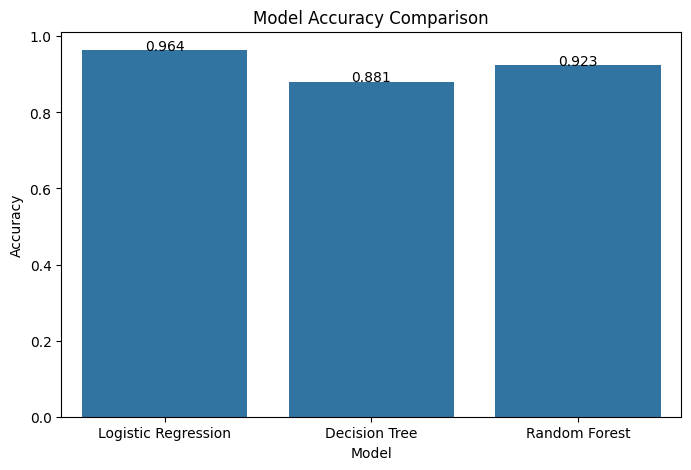

In [29]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=comparison
)

plt.title("Model Accuracy Comparison")

for i, v in enumerate(comparison["Accuracy"]):
    plt.text(i, v, f"{v:.3f}", ha='center')

plt.show()

finding the best model 

In [30]:
best_model = comparison.loc[
    comparison['Accuracy'].idxmax()
]

print(best_model)

Model       Logistic Regression
Accuracy               0.963938
Name: 0, dtype: object


In [31]:
import joblib

joblib.dump(lr, "stress_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully")

Model Saved Successfully
